<a href="https://colab.research.google.com/github/Meenakshimadhu192001/Case_study/blob/main/Copy_of_case_study_2_assesment_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import libraries

In [66]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt

# used for scaling numerical features
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# Symmetric distribution - standard scaler, non symmetric - min-max

#used to convert non numerical columns to numerical columns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
#label encoder is to be used only for target column nad binary features

#label encoder is to be used only for target column nad binary features
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression


from sklearn.metrics import accuracy_score,precision_score,recall_score

#for decision tree model
from sklearn.tree import DecisionTreeClassifier

#for evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier



In [67]:
#Load the dataset House_Pricing.csv
file_name ='/content/House_Pricing (3).csv'
df_price = pd.read_csv(file_name)
df_price.head(3)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062


In [68]:
#Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [69]:
df_price.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


##Duplicate Removal

In [70]:
#Duplicate Removal
#Rows: Check for duplicate rows in the dataset, if any, and remove them.
#Columns: Identify and drop duplicate columns, if any, based on their values

df_price.duplicated().sum() #removing of rows

np.int64(0)

In [71]:
df_price.T.duplicated().sum()  #removing of columns

np.int64(0)

In [72]:
df_price.drop_duplicates(inplace = True)

##Handling Missing Values

In [73]:

  #For categorical columns, fill with mode.
#Document your approach for each feature with missing data.

df_price.isna()#Handling Missing Values

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [74]:
df_price.isna().sum() #count of missing values

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [75]:
df_price.isnull().sum() #Identify missing values in each column.

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [76]:
#fetching numerical column
num_cols=df_price.select_dtypes(include=['int','float64']).columns
#fetching catogorical column
cat_cols=df_price.select_dtypes(include=['object']).columns
print(num_cols)
print(cat_cols)

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [77]:
#Handle missing values:
 #For numerical columns, use imputation techniques : median
for col in num_cols:
  df_price[col] = df_price[col].fillna(df_price[col].median())
df_price[col]

,Lot Area after Renovation (in Sqft)
0,5650
1,7639
2,8062
3,5000
4,7503
...,...
21608,1509
21609,7200
21610,2007
21611,1287


In [78]:
for col in num_cols:  #For numerical columns, use imputation techniques : mean
  df_price[col] = df_price[col].fillna(df_price[col].mean())
df_price[col]

,Lot Area after Renovation (in Sqft)
0,5650
1,7639
2,8062
3,5000
4,7503
...,...
21608,1509
21609,7200
21610,2007
21611,1287


In [79]:
for col in cat_cols:  #For categorical columns, use imputation techniques : mode

    df_price[col] = df_price[col].fillna(df_price[col].mode()[0])

df_price[col]

,Condition of the House
0,Fair
1,Fair
2,Fair
3,Excellent
4,Fair
...,...
21608,Fair
21609,Fair
21610,Fair
21611,Fair


##outlier removal

In [80]:
#outlier detection
for col in num_cols:
  Q1=df_price[col].quantile(0.25)
  Q3=df_price[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outlier = df_price[(df_price[col]<lower_bound) | (df_price[col]<upper_bound)]
  print(f"{col}:{len(outlier)}outliers")

ID:21613outliers
Sale Price:20454outliers
No of Bedrooms:21279outliers
No of Bathrooms:21056outliers
Flat Area (in Sqft):21030outliers
Lot Area (in Sqft):19190outliers
No of Floors:21605outliers
Overall Grade:19990outliers
Area of the House from Basement (in Sqft):20995outliers
Basement Area (in Sqft):21078outliers
Age of House (in Years):21613outliers
Renovated Year:0outliers
Zipcode:21613outliers
Latitude:21613outliers
Longitude:21357outliers
Living Area after Renovation (in Sqft):21069outliers
Lot Area after Renovation (in Sqft):19419outliers


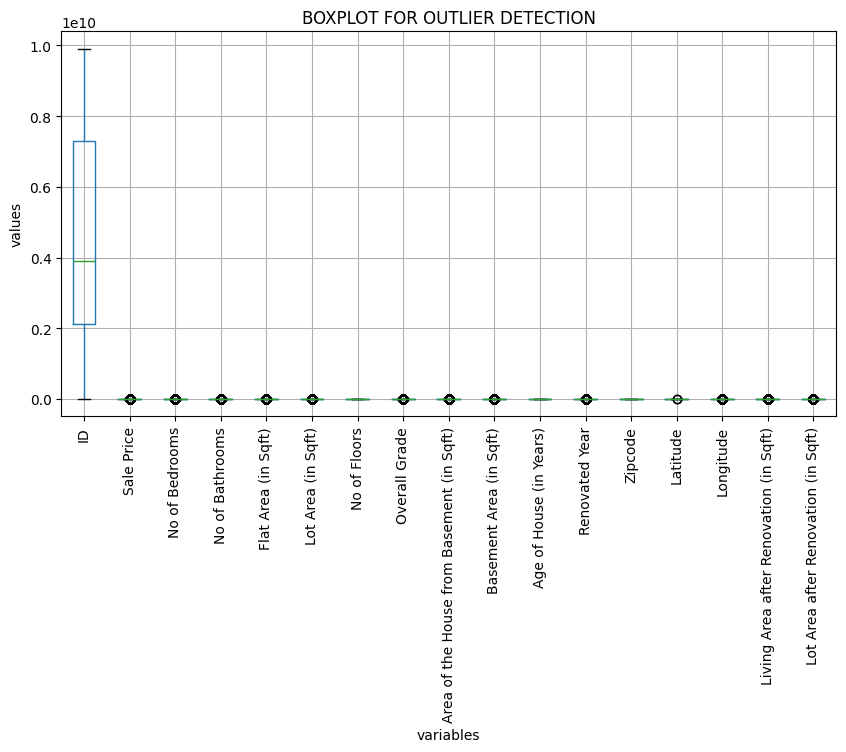

In [81]:
#boxplot
plt.figure(figsize=(10,5))
df_price[num_cols].boxplot(rot=90) #rotation of below text
plt.title('BOXPLOT FOR OUTLIER DETECTION')
plt.xlabel('variables')
plt.ylabel('values')
plt.show()

In [82]:
#removal of outliers
df_price = df_price[(df_price[col]>= lower_bound) & (df_price[col] <= upper_bound)]
df_price.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Twice,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Twice,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Twice,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Twice,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Twice,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


###Scaling Numerical Variables



In [83]:
#Identify all numerical columns (excluding the target variable SalePrice).


In [84]:
numerical_cols=df_price.select_dtypes(include=['int','float64']).columns
numerical_cols = numerical_cols.drop('Sale Price')
print(numerical_cols)


Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


##Scaling
we need to check the data distribution of continous feactures
1. min max scaler:used for skewed distribution Result - values are scaled in between 0 and 1
2. 2. std scaler:used for symmetrical distribution Result - values are scaled in such a way that mean= 0 and std= 1

In [85]:
#Scale these features using techniques like Min-Max scaling or Standard scaling
# object for standard scaling
stand_scalar = StandardScaler()
df_price[numerical_cols] = stand_scalar.fit_transform(df_price[numerical_cols])
df_price[numerical_cols]

,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.841260,-0.378669,-1.439887,-0.974062,-0.177635,-0.899240,-0.527706,-0.707379,-0.672391,0.503550,-0.203876,1.795194,-0.376073,-0.223419,-0.909629,-0.496544
1,0.592446,-0.378669,0.225102,0.675026,-0.069420,0.935232,-0.527706,0.605686,0.262875,0.636418,4.891321,0.816067,1.165208,-0.692572,-0.360461,0.119947
2,0.320184,-1.450588,-1.439887,-1.460483,0.118054,-0.899240,-1.479990,-1.251174,-0.672391,1.234321,-0.203876,-0.975920,1.289363,-0.041811,1.255663,0.251056
3,-0.773699,0.693251,1.224096,-0.048674,-0.221819,-0.899240,-0.527706,-0.879802,1.455339,0.171382,-0.203876,1.019282,-0.305547,-1.252528,-0.878248,-0.698012
4,-0.959057,-0.378669,-0.107895,-0.380865,-0.012457,-0.899240,0.424578,-0.044215,-0.672391,-0.559389,-0.203876,-0.126112,0.399710,1.380782,-0.187865,0.077794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,-1.547485,-0.378669,0.558100,-0.558824,-0.484812,2.769705,0.424578,-0.243164,-0.672391,-1.290160,-0.203876,0.409637,1.005791,-0.896880,-0.611509,-1.780049
21609,0.657140,0.693251,0.558100,0.366564,-0.166555,0.935232,0.424578,0.791372,-0.672391,-1.456244,-0.203876,1.204023,-0.379746,-1.017952,-0.140794,-0.016121
21610,-1.109034,-1.450588,-1.772885,-1.163885,-0.469926,0.935232,-0.527706,-0.919592,-0.672391,-1.290160,-0.203876,1.167075,0.235150,-0.541232,-1.411726,-1.625694
21611,-1.537636,-0.378669,0.558100,-0.475776,-0.399368,0.935232,0.424578,-0.150321,-0.672391,-1.124076,-0.203876,-0.994394,-0.204901,1.199174,-0.799796,-1.848858


In [86]:
# after scaling
df_price.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.841260,14 October 2017,221900.0,-0.378669,-1.439887,-0.974062,-0.177635,-0.899240,No,Twice,...,-0.527706,-0.707379,-0.672391,0.503550,-0.203876,1.795194,-0.376073,-0.223419,-0.909629,-0.496544
1,0.592446,14 December 2017,538000.0,-0.378669,0.225102,0.675026,-0.069420,0.935232,No,Twice,...,-0.527706,0.605686,0.262875,0.636418,4.891321,0.816067,1.165208,-0.692572,-0.360461,0.119947
2,0.320184,15 February 2016,180000.0,-1.450588,-1.439887,-1.460483,0.118054,-0.899240,No,Twice,...,-1.479990,-1.251174,-0.672391,1.234321,-0.203876,-0.975920,1.289363,-0.041811,1.255663,0.251056
3,-0.773699,14 December 2017,604000.0,0.693251,1.224096,-0.048674,-0.221819,-0.899240,No,Twice,...,-0.527706,-0.879802,1.455339,0.171382,-0.203876,1.019282,-0.305547,-1.252528,-0.878248,-0.698012
4,-0.959057,15 February 2016,510000.0,-0.378669,-0.107895,-0.380865,-0.012457,-0.899240,No,Twice,...,0.424578,-0.044215,-0.672391,-0.559389,-0.203876,-0.126112,0.399710,1.380782,-0.187865,0.077794


###Encoding Categorical Variables

In [87]:
cat_cols   #identify all categorical columns in the dataset

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [88]:
numerical_cols     #identify all categorical columns in the dataset

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [89]:
cat_cols   #identify all categorical columns in the dataset

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

One hot encoding

In [90]:
feature_cat_cols = ['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House']#OHE

In [91]:
df_price['Date House was Sold'].unique()

array(['14 October 2017', '14 December 2017', '15 February 2016',
       '14 June 2017', '15 January 2016', '15 April 2016',
       '15 March 2016', '14 May 2017', '14 July 2017', '14 November 2017',
       '14 September 2017', '14 August 2017', '15 May 2016'], dtype=object)

In [92]:
df_price[ 'Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

In [93]:
df_price[  'No of Times Visited'].unique()

array(['Twice', 'Thrice', 'Four', 'Once'], dtype=object)

In [94]:
df_price[ 'Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [95]:
ohe_cols = ['Date House was Sold', 'Waterfront View' , 'No of Times Visited',  #OHE
            'Condition of the House']
df_price_ohe = pd.get_dummies(df_price , columns=ohe_cols , dtype = int)
df_price_ohe.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Waterfront View_Yes,No of Times Visited_Four,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,0.841260,221900.0,-0.378669,-1.439887,-0.974062,-0.177635,-0.899240,-0.527706,-0.707379,-0.672391,...,0,0,0,0,1,0,0,1,0,0
1,0.592446,538000.0,-0.378669,0.225102,0.675026,-0.069420,0.935232,-0.527706,0.605686,0.262875,...,0,0,0,0,1,0,0,1,0,0
2,0.320184,180000.0,-1.450588,-1.439887,-1.460483,0.118054,-0.899240,-1.479990,-1.251174,-0.672391,...,0,0,0,0,1,0,0,1,0,0
3,-0.773699,604000.0,0.693251,1.224096,-0.048674,-0.221819,-0.899240,-0.527706,-0.879802,1.455339,...,0,0,0,0,1,0,1,0,0,0
4,-0.959057,510000.0,-0.378669,-0.107895,-0.380865,-0.012457,-0.899240,0.424578,-0.044215,-0.672391,...,0,0,0,0,1,0,0,1,0,0


##Train-Test Split
1. Set aside the SalePrice column as the target variable.
Split the dataset into training (80%) and testing (20%) sets using the train_test_split function from sklearn.

In [96]:
#define x and y
#Set aside the SalePrice column as the target variable.
# y = what we want to PREDICT
y = df_price['Sale Price']

# X = all columns EXCEPT Sale Price
X = df_price.drop(columns=['Sale Price'])

print("X shape:", X.shape)  # rows, 20 columns
print("y shape:", y.shape)  # rows, Sale Price onl

X shape: (19419, 20)
y shape: (19419,)


In [97]:
##Split into 80% Train & 20% Test:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)


In [98]:
#verify the split
print("X_train:", X_train.shape) #80% of input columns
print("X_test:", X_test.shape) #20% of input columns
print("y_train:", y_train.shape) #80% of Sale Prices
print("y_test:", y_test.shape) #20% of Sale Prices

X_train: (15535, 20)
X_test: (3884, 20)
y_train: (15535,)
y_test: (3884,)


#Model building

####Checking the data before ML model building



In [99]:
df_price.dtypes

,0
ID,float64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


In [100]:
y_train

,Sale Price
10867,750000.0
6031,300000.0
9427,275000.0
12891,582000.0
7531,255000.0
...,...
12636,585000.0
13407,790000.0
6073,800000.0
979,427200.0


###Splitting data

In [101]:
#spliting data into target and
y = df_price['Sale Price']
X = df_price.drop('Sale Price',axis =1)
#splitting into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [102]:
X_test.head(3)

,ID,Date House was Sold,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
15577,-0.465013,14 July 2017,-0.378669,-0.107895,-0.274089,-0.068808,-0.899240,No,Twice,Good,0.424578,0.075154,-0.672391,-0.659040,-0.203876,-0.920498,-1.129082,0.434909,1.004615,-0.013022
12846,-1.491450,14 December 2017,0.693251,1.557094,2.169883,0.118394,0.935232,No,Twice,Fair,2.329145,2.807390,-0.672391,-1.024425,-0.203876,-0.107638,0.241762,1.426184,0.996769,-0.634782
997,-0.297188,14 August 2017,-1.450588,-1.439887,-1.365572,-0.402631,-0.899240,No,Twice,Fair,-0.527706,-1.145067,-0.672391,1.599707,-0.203876,0.446585,0.795683,-0.760675,-0.972391,-1.317913


In [103]:
y_test.head(3)

,Sale Price
15577,320900.0
12846,860000.0
997,553500.0


In [104]:
#check whether the dataframe is all numerical
df_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19419 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         19419 non-null  float64
 1   Date House was Sold                        19419 non-null  object 
 2   Sale Price                                 19419 non-null  float64
 3   No of Bedrooms                             19419 non-null  float64
 4   No of Bathrooms                            19419 non-null  float64
 5   Flat Area (in Sqft)                        19419 non-null  float64
 6   Lot Area (in Sqft)                         19419 non-null  float64
 7   No of Floors                               19419 non-null  float64
 8   Waterfront View                            19419 non-null  object 
 9   No of Times Visited                        19419 non-null  object 
 10  Condition of the House     

In [105]:
print(X_train.select_dtypes(include='object').columns)

for col in X_train.select_dtypes(include='object').columns:
    print(col, ":", X_train[col].unique()[:5])

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')
Date House was Sold : ['15 May 2016' '15 January 2016' '15 March 2016' '14 July 2017'
 '14 December 2017']
Waterfront View : ['No' 'Yes']
No of Times Visited : ['Twice' 'Four' 'Thrice' 'Once']
Condition of the House : ['Fair' 'Good' 'Excellent' 'Okay' 'Bad']


In [106]:
df_price['Date House was Sold'] = pd.to_datetime(df_price['Date House was Sold'])
df_price['Sale_year'] = df_price['Date House was Sold'].dt.year
df_price['month'] = df_price['Date House was Sold'].dt.month
df_price['day'] = df_price['Date House was Sold'].dt.day
df_price.drop('Date House was Sold', axis=1, inplace=True)

In [107]:
X_train = X_train.drop(columns=["No of Times Visited"])
X_test = X_test.drop(columns=["No of Times Visited"])

In [108]:
X_train["Waterfront View"] = X_train["Waterfront View"].map({"No": 0,"Yes": 1})
X_test["Waterfront View"] = X_test["Waterfront View"].map({"No": 0,"Yes": 1})

In [109]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_train["Condition of the House"] = le.fit_transform(X_train["Condition of the House"].astype(str))
X_test["Condition of the House"] = le.transform(X_test["Condition of the House"].astype(str))

In [110]:
print(X_train.select_dtypes(include="object").columns)

Index(['Date House was Sold'], dtype='object')


In [111]:
print(X_train.dtypes)
print(X_train.select_dtypes(include='object').columns)

ID                                           float64
Date House was Sold                           object
No of Bedrooms                               float64
No of Bathrooms                              float64
Flat Area (in Sqft)                          float64
Lot Area (in Sqft)                           float64
No of Floors                                 float64
Waterfront View                                int64
Condition of the House                         int64
Overall Grade                                float64
Area of the House from Basement (in Sqft)    float64
Basement Area (in Sqft)                      float64
Age of House (in Years)                      float64
Renovated Year                               float64
Zipcode                                      float64
Latitude                                     float64
Longitude                                    float64
Living Area after Renovation (in Sqft)       float64
Lot Area after Renovation (in Sqft)          f

##Linear Regression

In [113]:
print(X_train.dtypes)

ID                                           float64
Date House was Sold                           object
No of Bedrooms                               float64
No of Bathrooms                              float64
Flat Area (in Sqft)                          float64
Lot Area (in Sqft)                           float64
No of Floors                                 float64
Waterfront View                                int64
Condition of the House                         int64
Overall Grade                                float64
Area of the House from Basement (in Sqft)    float64
Basement Area (in Sqft)                      float64
Age of House (in Years)                      float64
Renovated Year                               float64
Zipcode                                      float64
Latitude                                     float64
Longitude                                    float64
Living Area after Renovation (in Sqft)       float64
Lot Area after Renovation (in Sqft)          f

In [114]:
# X_train fix
X_train['Date House was Sold'] = pd.to_datetime(X_train['Date House was Sold'])
X_train['Sale_year'] = X_train['Date House was Sold'].dt.year
X_train['month'] = X_train['Date House was Sold'].dt.month
X_train['day'] = X_train['Date House was Sold'].dt.day
X_train = X_train.drop(columns=['Date House was Sold'])

# X_test fix (same steps)
X_test['Date House was Sold'] = pd.to_datetime(X_test['Date House was Sold'])
X_test['Sale_year'] = X_test['Date House was Sold'].dt.year
X_test['month'] = X_test['Date House was Sold'].dt.month
X_test['day'] = X_test['Date House was Sold'].dt.day
X_test = X_test.drop(columns=['Date House was Sold'])

# Check cheyyuka
print(X_train.dtypes)

ID                                           float64
No of Bedrooms                               float64
No of Bathrooms                              float64
Flat Area (in Sqft)                          float64
Lot Area (in Sqft)                           float64
No of Floors                                 float64
Waterfront View                                int64
Condition of the House                         int64
Overall Grade                                float64
Area of the House from Basement (in Sqft)    float64
Basement Area (in Sqft)                      float64
Age of House (in Years)                      float64
Renovated Year                               float64
Zipcode                                      float64
Latitude                                     float64
Longitude                                    float64
Living Area after Renovation (in Sqft)       float64
Lot Area after Renovation (in Sqft)          float64
Sale_year                                     

In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [120]:
#  LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lin_reg = LinearRegression()

lin_reg.fit(X_train_scaled, y_train)

y_pred_lin_reg = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, y_pred_lin_reg))
print("MSE :", mean_squared_error(y_test, y_pred_lin_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin_reg)))
print("R² Score:", r2_score(y_test, y_pred_lin_reg))

Linear Regression
MAE : 122640.3961099393
MSE : 33016046998.0743
RMSE: 181703.18378629006
R² Score: 0.6942557314432405


In [ ]:
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² Score:", r2_score(y_test, y_pred_rf))